In [5]:
import pandas_gbq

project_id = "lewagonyining"

query = """
    SELECT *
    FROM `lewagonyining.neo_bank.users`
    LIMIT 1000
"""

# Fetch data directly into a pandas DataFrame
df = pandas_gbq.read_gbq(query, project_id=project_id)

Downloading: 100%|██████████|


In [6]:
from google.cloud import bigquery
import pandas as pd

# Initialise the BigQuery client
client = bigquery.Client(project="lewagonyining")

# Load the users table into a pandas DataFrame
query = """
    SELECT *
    FROM `lewagonyining.neo_bank.users`
"""
df_users = client.query(query).to_dataframe()

# Check for null values in each column
print("Null count per column:")
print(df_users.isnull().sum())

# Replace all null values with 0
df_users_cleaned = df_users.fillna(0)

# Verify nulls have been replaced
print("\nNull count after cleaning:")
print(df_users_cleaned.isnull().sum())

/home/yiningl/.pyenv/versions/lewagon/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Null count per column:
user_id                                        0
birth_year                                     0
country                                        0
city                                           0
created_date                                   0
user_settings_crypto_unlocked                  0
plan                                           0
attributes_notifications_marketing_push     6610
attributes_notifications_marketing_email    6610
num_contacts                                   0
num_referrals                                  0
num_successful_referrals                       0
dtype: int64

Null count after cleaning:
user_id                                     0
birth_year                                  0
country                                     0
city                                        0
created_date                                0
user_settings_crypto_unlocked               0
plan                                        0
attributes_notifications_m

In [7]:
# Load the transactions table into a pandas DataFrame
query = """
    SELECT *
    FROM `lewagonyining.neo_bank.transactions`
"""
df_transactions = client.query(query).to_dataframe()

# Check for null values in each column
print("\nNull count per column:")
print(df_transactions.isnull().sum())

# Replace all null values with 0
df_transactions_cleaned = df_transactions.fillna(0)

# Verify nulls have been replaced
print("\nNull count after cleaning:")
print(df_transactions_cleaned.isnull().sum())


Null count per column:
transaction_id                 0
transactions_type              0
transactions_currency          0
amount_usd                     0
transactions_state             0
ea_cardholderpresence    1170594
ea_merchant_mcc          1158658
ea_merchant_city         1158794
ea_merchant_country      1158979
direction                      0
user_id                        0
created_date                   0
dtype: int64

Null count after cleaning:
transaction_id           0
transactions_type        0
transactions_currency    0
amount_usd               0
transactions_state       0
ea_cardholderpresence    0
ea_merchant_mcc          0
ea_merchant_city         0
ea_merchant_country      0
direction                0
user_id                  0
created_date             0
dtype: int64


In [8]:
import json

# Pre-calculate the total unique transactions count
tx_summary = {
    "total_tx_count": int(df_transactions_cleaned["transaction_id"].nunique())
}

# Save as a tiny JSON file (less than 1 KB)
with open("data/tx_summary.json", "w") as f:
    json.dump(tx_summary, f)

In [1]:
import pandas as pd

# Load raw files
df_transactions_cleaned = pd.read_csv("data/df_transactions_cleaned.csv")
df_users = pd.read_csv("data/df_users_cleaned.csv")

# Ensure datetime parsing
df_transactions_cleaned["created_date"] = pd.to_datetime(
    df_transactions_cleaned["created_date"], format="mixed"
)

# Calculate decade bins for users
min_year = int(df_users["birth_year"].min())
max_year = int(df_users["birth_year"].max())
start_decade = (min_year // 10) * 10
end_decade = ((max_year // 10) + 1) * 10
bins = list(range(start_decade, end_decade + 10, 10))
labels = [f"{b}s" for b in bins[:-1]]

# Create decade column and cast directly to string type
df_users["decade"] = pd.cut(
    df_users["birth_year"], bins=bins, labels=labels, right=False
).astype(str)

# Merge country AND decade into transactions
df_merged = df_transactions_cleaned.merge(
    df_users[["user_id", "country", "decade"]], on="user_id", how="left"
)

# Group by created_date, country, AND decade
daily_summary = (
    df_merged[df_merged["transactions_state"] == "COMPLETED"]
    .groupby([pd.Grouper(key="created_date", freq="D"), "country", "decade"], observed=False)
    .agg(
        daily_volume=("amount_usd", "sum"),
        transaction_count=("transaction_id", "count"),
    )
    .reset_index()
)

# Ensure string type before saving
daily_summary["decade"] = daily_summary["decade"].astype(str)
daily_summary["country"] = daily_summary["country"].astype(str)

# Export the enhanced summary file
daily_summary.to_csv("data/df_daily_transaction_summary.csv", index=False)

In [3]:
import pandas as pd

# Load datasets
df_users = pd.read_csv("data/df_users_cleaned.csv")
df_transactions = pd.read_csv("data/df_transactions_cleaned.csv")

# 1. Total Onboarded Users
total_onboarded = len(df_users)

# 2. Marketing Opt-In Users (Push or Email)
opt_in_mask = (
    (df_users["attributes_notifications_marketing_push"] == 1) |
    (df_users["attributes_notifications_marketing_email"] == 1)
)
total_opt_in = opt_in_mask.sum()

# 3. Retained Users (Active in the last 60 days before 2019-05-16)
df_transactions["created_date"] = pd.to_datetime(
    df_transactions["created_date"], format="mixed"
)

# Strip timezone awareness if present to avoid naive/aware comparison errors
if df_transactions["created_date"].dt.tz is not None:
    df_transactions["created_date"] = df_transactions["created_date"].dt.tz_localize(None)

cutoff_date = pd.to_datetime("2019-05-16")
start_active_window = cutoff_date - pd.Timedelta(days=60)

# Identify users who completed at least one transaction in that 60-day window
active_user_ids = df_transactions[
    (df_transactions["transactions_state"] == "COMPLETED") &
    (df_transactions["created_date"] >= start_active_window) &
    (df_transactions["created_date"] <= cutoff_date)
]["user_id"].unique()

total_retained = df_users["user_id"].isin(active_user_ids).sum()

# Save summary dataframe
df_funnel = pd.DataFrame({
    "Stage": ["1. Total Onboarded", "2. Marketing Opt-In", "4. Retained Users"],
    "Count": [total_onboarded, total_opt_in, total_retained]
})
df_funnel.to_csv("data/df_conversion_funnel.csv", index=False)

In [9]:
# Load the devices table into a pandas DataFrame
query = """
    SELECT *
    FROM `lewagonyining.neo_bank.devices`
"""
df_devices = client.query(query).to_dataframe()

# Check for null values in each column
print("\nNull count per column:")
print(df_devices.isnull().sum())


Null count per column:
string_field_0    0
string_field_1    0
dtype: int64


In [10]:
# Load the notifications table into a pandas DataFrame
query = """
    SELECT *
    FROM `lewagonyining.neo_bank.notifications`
"""
df_notifications = client.query(query).to_dataframe()

# Check for null values in each column
print("\nNull count per column:")
print(df_notifications.isnull().sum())


Null count per column:
reason          0
channel         0
status          0
user_id         0
created_date    0
dtype: int64


In [11]:
import pandas as pd

# 1. Define snapshot date in UTC to match BigQuery timestamps
SNAPSHOT_DATE = pd.Timestamp('2019-05-16', tz='UTC')

# 2. Filter completed transactions and aggregate user metrics
completed_tx = df_transactions_cleaned[
    df_transactions_cleaned['transactions_state'] == 'COMPLETED'
].copy()

# Normalize transaction timestamps to timezone-aware UTC values
completed_tx['created_date'] = pd.to_datetime(
    completed_tx['created_date'], utc=True
)

tx_aggregated = (
    completed_tx.groupby('user_id')
    .agg(
        num_completed_transactions=('transaction_id', 'count'),
        total_completed_amount_usd=('amount_usd', 'sum'),
        last_transaction_date=('created_date', 'max'),
    )
    .reset_index()
)

# 3. Join with user features
user_features = df_users_cleaned[[
    'user_id',
    'user_settings_crypto_unlocked',
    'attributes_notifications_marketing_push',
    'attributes_notifications_marketing_email',
    'num_contacts'
]].copy()

df_model = pd.merge(user_features, tx_aggregated, on='user_id', how='left')

# 4. Fill missing values
df_model['num_completed_transactions'] = df_model[
    'num_completed_transactions'
].fillna(0)
df_model['total_completed_amount_usd'] = df_model[
    'total_completed_amount_usd'
].fillna(0)

# 5. Calculate Days Inactive & Churn Label
df_model['days_inactive'] = (
    SNAPSHOT_DATE - df_model['last_transaction_date']
).dt.days

df_model['churn'] = (
    (df_model['days_inactive'] > 60) | (df_model['last_transaction_date'].isna())
).astype(int)

In [12]:
from sklearn.model_selection import train_test_split

# 6. Separate X and y for the Logistic Regression

X_cols = [
    'user_settings_crypto_unlocked',
    'attributes_notifications_marketing_push',
    'attributes_notifications_marketing_email',
    'num_contacts',
    'num_completed_transactions',
    'total_completed_amount_usd'
]

X = df_model[X_cols]
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 1. Train as a unified pipeline
clf_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight="balanced", random_state=42),
)

# 2. Fit on training data
clf_pipeline.fit(X_train, y_train)

# 3. Save pipeline to pickle
joblib.dump(clf_pipeline, "churn_model.pkl")

['churn_model.pkl']

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score

baseline_y_pred = np.zeros(len(y_test))

baseline_accuracy = accuracy_score(y_test, baseline_y_pred)

print(f"Baseline accuracy is {round(baseline_accuracy,2)}")

Baseline accuracy is 0.65


In [15]:
from sklearn.linear_model import LogisticRegression

# train model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# store predictions
y_pred = clf.predict(X_test)

/home/yiningl/.pyenv/versions/lewagon/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
import joblib

# Export your trained Logistic Regression model
joblib.dump(clf, 'churn_model.pkl')

print("Model successfully saved as churn_model.pkl!")

Model successfully saved as churn_model.pkl!


In [17]:
from sklearn.metrics import accuracy_score

accuracy_test = accuracy_score(y_test, y_pred)
accuracy_test

0.7938754503345342

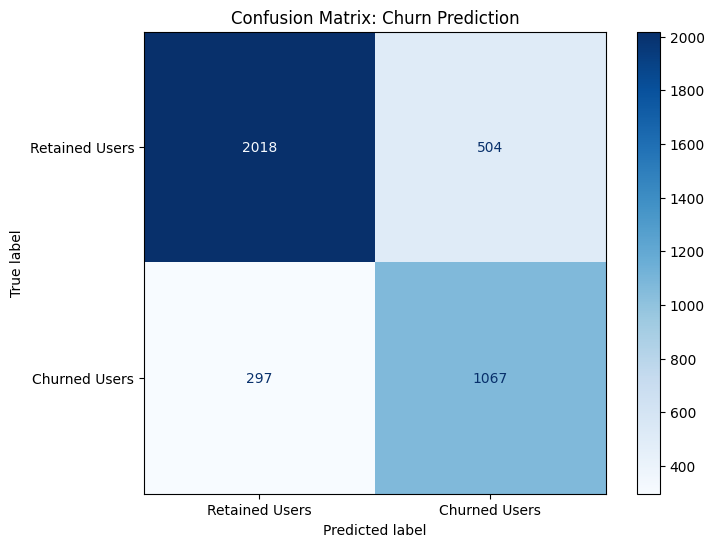

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test,
    labels=[0, 1],
    display_labels=["Retained Users", "Churned Users"],
    cmap='Blues',
    ax=ax
)
plt.title('Confusion Matrix: Churn Prediction')
plt.show()

In [19]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, classification_report

# Calculate all metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Precision: {precision:.1%}")
print(f"Recall:    {recall:.1%}")
print(f"Accuracy:  {accuracy:.1%}")

# Even better: Get a full report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Retained Users", "Churned Users"]))

Precision: 67.9%
Recall:    78.2%
Accuracy:  79.4%

Classification Report:
                precision    recall  f1-score   support

Retained Users       0.87      0.80      0.83      2522
 Churned Users       0.68      0.78      0.73      1364

      accuracy                           0.79      3886
     macro avg       0.78      0.79      0.78      3886
  weighted avg       0.80      0.79      0.80      3886



In [20]:
# View total count of retained (0) vs churned (1) users
print(y_train.value_counts())

churn
0    10079
1     5465
Name: count, dtype: int64


In [21]:
# Check feature importance (coefficients)
feature_names = [
    'user_settings_crypto_unlocked',
    'attributes_notifications_marketing_push',
    'attributes_notifications_marketing_email',
    'num_contacts',
    'num_completed_transactions',
    'total_completed_amount_usd'
]

# Extract coefficients
coef_df = pd.DataFrame(
    {'Feature': feature_names, 'Coefficient': clf.coef_[0]}
).sort_values(by='Coefficient', ascending=False)

print("--- Model Intercept ---")
print(clf.intercept_[0])

print("\n--- Feature Coefficients ---")
print(coef_df)

--- Model Intercept ---
0.9089412429848358

--- Feature Coefficients ---
                                    Feature  Coefficient
1   attributes_notifications_marketing_push     0.047649
5                total_completed_amount_usd    -0.000022
4                num_completed_transactions    -0.019744
3                              num_contacts    -0.025433
2  attributes_notifications_marketing_email    -0.075357
0             user_settings_crypto_unlocked    -0.147689


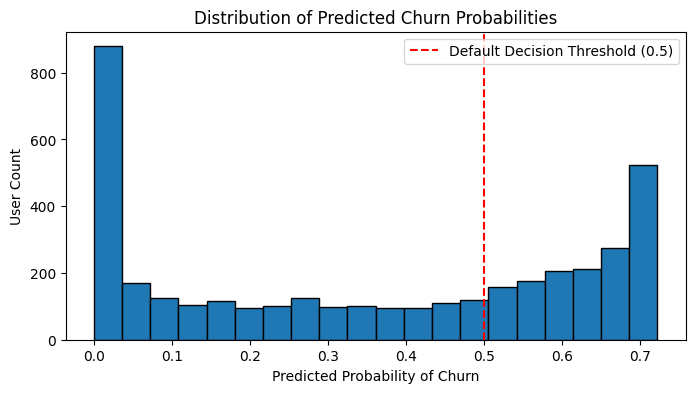

In [22]:
import matplotlib.pyplot as plt

# Get churn probabilities for the test set
y_probs = clf.predict_proba(X_test)[0:, 1]

# Plot probability distribution
plt.figure(figsize=(8, 4))
plt.hist(y_probs, bins=20, edgecolor='black')
plt.title('Distribution of Predicted Churn Probabilities')
plt.xlabel('Predicted Probability of Churn')
plt.ylabel('User Count')
plt.axvline(
    0.5, color='red', linestyle='--', label='Default Decision Threshold (0.5)'
)
plt.legend()
plt.show()